## Chargement des packages 


In [27]:
library(tidyverse)
library(ggplot2)
library(corrplot)
library(FactoMineR)
library(factoextra)
library(vcd)       # mosaicplot
library(GGally)    # ggpairs

# Analyse exploratoire des données 

## 1. Chargement et vérification des données 

In [63]:
df <- read.csv("healthcare_synthetic_data.csv", stringsAsFactors = FALSE)


#### 1.1 Dimensions et aperçu général 

In [64]:
head(df)
cat("Dimensions du dataset: ",dim(df))
anyDuplicated(df$ID_patient)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


Dimensions du dataset:  15000 19

[1] 0

Le jeu de données contient bien **15 000 patients** (nombre de ligne) et **19 variables** (nombre de colonne).  
La variable `Patient_ID` est un identifiant unique : elle sera **supprimée** pour l'analyse. On vérifie que la colonne Patient_ID est a valeur unique avec la commande
**anyDuplicated** retournant 0 si il n'y a pas de doublons.
Les variables qualitatives sont déjà encodées sous forme d'entiers, il faudra les convertir en **facteurs** pour que R les traite correctement.

In [65]:
str(df)
cat("\nValeurs manquantes par variable :\n")
print(colSums(is.na(df)))
df <- df %>% select(-Patient_ID)

'data.frame':	15000 obs. of  19 variables:
 $ Patient_ID             : chr  "PID-00001" "PID-00002" "PID-00003" "PID-00004" ...
 $ Age                    : int  60 53 62 73 52 52 73 64 49 61 ...
 $ Gender                 : int  0 0 1 1 1 0 0 0 0 1 ...
 $ Height_cm              : num  147 162 175 173 179 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 79.8 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 25 23.7 25 34.5 28.2 36.3 ...
 $ Systolic_BP            : int  140 128 141 136 122 134 149 129 139 131 ...
 $ Diastolic_BP           : int  89 81 100 96 80 92 98 90 91 91 ...
 $ Cholesterol_Total      : int  217 203 173 193 236 225 260 237 227 206 ...
 $ Cholesterol_LDL        : int  151 119 124 117 153 155 166 160 138 139 ...
 $ Cholesterol_HDL        : int  52 38 45 45 41 48 46 44 37 38 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 79 103 103 108 90 103 ...
 $ Smoking_Status         : int  0 0 0 0 0 0 0 0 1 0 ...
 $ Alcohol_Consumption    : int  1 0 0 0 1 0 0 1 0 

Aucune valeur manquante n'est détectée dans le jeu de données.  
La variable `Patient_ID` a été supprimée car elle n'apporte aucune information prédictive.

Les variables qualitatives suivantes sont encodées en entiers et doivent être converties en facteurs :

| Variable                   | Encodage                                          |
| -------------------------- | ------------------------------------------------- |
| `Genre`                    | 0 = Femme, 1 = Homme                              |
| `Statut_Tabac`             | 0 = Non-fumeur, 1 = Fumeur                        |
| `Consommation_Alcool`      | 0 = Aucune, 1 = Modérée, 2 = Élevée               |
| `Niveau_Activité_Physique` | 0 = Aucun, 1 = Faible, 2 = Modéré, 3 = Élevé |
| `Antécédents_Familiaux`    | 0 = Non, 1 = Oui                                  |
| `Risque_Maladie_Cardiaque` | 0 = Risque faible, 1 = Risque élevé               |


#### 1.2 Conversion des variables qualitatives

In [67]:
df[,"Smoking_Status"]<- as.factor(df[,"Smoking_Status"])
df[,"Gender"]<- as.factor(df[,"Gender"])
df[,"Family_History"]<- as.factor(df[,"Family_History"])
df[,"Heart_Disease_Risk"]<- as.factor(df[,"Heart_Disease_Risk"])
df[,"Alcohol_Consumption"]<- as.factor(df[,"Alcohol_Consumption"])
df[,"Physical_Activity_Level"]<- as.factor(df[,"Physical_Activity_Level"])

#### 1.3 Statistique descriptive 

In [68]:
summary(df)

      Age        Gender     Height_cm       Weight_kg           BMI       
 Min.   :25.00   0:7622   Min.   :138.5   Min.   : 33.70   Min.   :14.50  
 1st Qu.:46.00   1:7378   1st Qu.:158.5   1st Qu.: 65.20   1st Qu.:24.50  
 Median :55.00            Median :164.7   Median : 73.90   Median :27.20  
 Mean   :54.54            Mean   :165.3   Mean   : 75.25   Mean   :27.45  
 3rd Qu.:63.00            3rd Qu.:172.0   3rd Qu.: 83.90   3rd Qu.:30.00  
 Max.   :85.00            Max.   :198.1   Max.   :150.10   Max.   :46.10  
  Systolic_BP     Diastolic_BP    Cholesterol_Total Cholesterol_LDL
 Min.   : 90.0   Min.   : 60.00   Min.   :127.0     Min.   : 70.0  
 1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0     1st Qu.:128.0  
 Median :135.0   Median : 91.00   Median :216.0     Median :140.0  
 Mean   :135.1   Mean   : 90.54   Mean   :216.2     Mean   :140.4  
 3rd Qu.:143.0   3rd Qu.: 96.00   3rd Qu.:231.0     3rd Qu.:152.0  
 Max.   :182.0   Max.   :120.00   Max.   :303.0     Max.   :210.0  

##### 1.3.1 Statistque unidimensionnelle

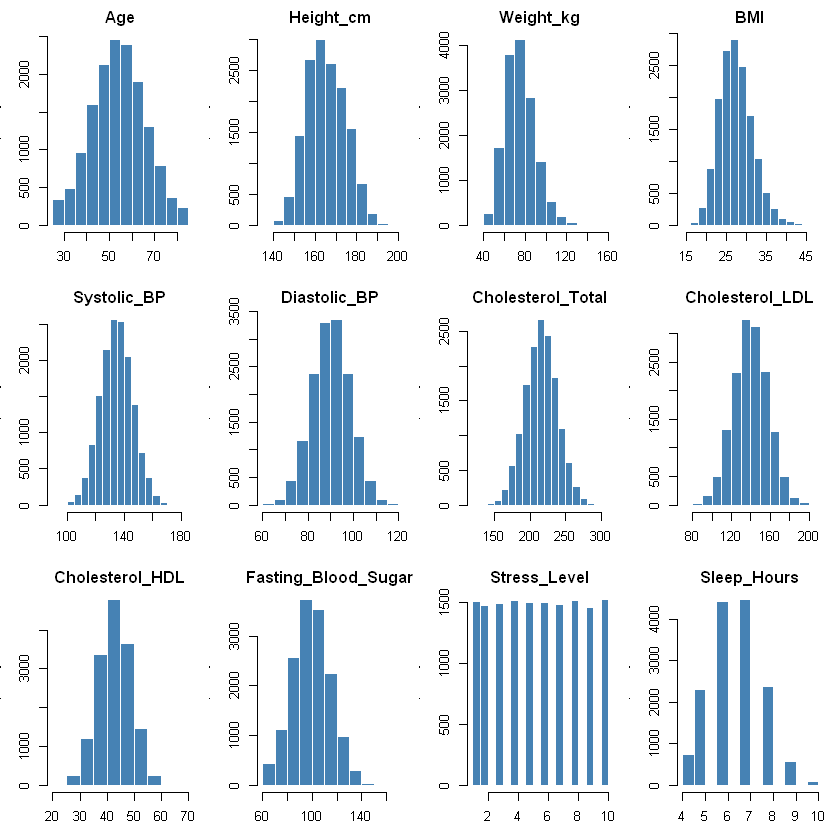

In [69]:
quant_cols <- c("Age", "Height_cm", "Weight_kg", "BMI",
                "Systolic_BP", "Diastolic_BP", "Cholesterol_Total",
                "Cholesterol_LDL", "Cholesterol_HDL",
                "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours")
par(mfrow = c(3, 4), mar = c(3, 3, 2, 1))

for (col in quant_cols) {
  hist(df[[col]],
       main  = col,
       xlab  = col,
       col   = "steelblue",
       border = "white")
}

par(mfrow = c(1, 1))